In [3]:

import os
import random
import requests
import warnings
from datetime import datetime
from datetime import datetime, timedelta

import holidays
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import itertools


# Suppress warnings
warnings.filterwarnings('ignore')

# Statistical and ML libraries
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import SelectKBest, f_classif

# Time series specific libraries
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from scipy import stats 

# Deep learning libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [6]:
df = pd.read_csv(r'C:\Users\TPWODL\New folder_Content\DeepLearning_TimeSeries_LSTM_End_To_End\data\raw\twitter_complaint_data.csv')

In [8]:
df.set_index("time", inplace=True)

In [10]:
df

,day_temperature_C,day_humidity_percent,dayofweek_sin,dayofweek_cos,dayofmonth_sin,dayofmonth_cos,dayofyear_sin,dayofyear_cos,complaint_count
time,,,,,,,,,
2022-06-10,34.6,47,-0.433884,-0.900969,8.978045e-01,-0.440394,0.361714,-0.932289,10.0
2022-06-11,34.8,42,-0.974928,-0.222521,7.907757e-01,-0.612106,0.345612,-0.938377,12.0
2022-06-12,34.4,45,-0.781831,0.623490,6.513725e-01,-0.758758,0.329408,-0.944188,5.0
2022-06-13,34.7,45,0.000000,1.000000,4.853020e-01,-0.874347,0.313107,-0.949718,15.0
2022-06-14,32.9,52,0.781831,0.623490,2.993631e-01,-0.954139,0.296713,-0.954967,16.0
...,...,...,...,...,...,...,...,...,...
2025-10-29,26.2,86,0.974928,-0.222521,-3.943559e-01,0.918958,-0.884068,0.467359,43.0
2025-10-30,26.6,83,0.433884,-0.900969,-2.012985e-01,0.979530,-0.875892,0.482508,23.0
2025-10-31,26.4,85,-0.433884,-0.900969,-2.449294e-16,1.000000,-0.867456,0.497513,26.0


In [11]:
# Separate features (X) and target (y)
X = df.drop(columns=['complaint_count'])
y = df['complaint_count']
# Split data into train and test sets (80-20 split)
train_size = int(len(df) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
# Print shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print(f"Training set size: {len(y_train)}")
print(f"Test set size: {len(y_test)}")
print(f"Date range - Train: {df.index[0]} to {df.index[train_size-1]}")
print(f"Date range - Test: {df.index[train_size]} to {df.index[-1]}")

X_train shape: (993, 8)
X_test shape: (249, 8)
y_train shape: (993,)
y_test shape: (249,)
Training set size: 993
Test set size: 249
Date range - Train: 2022-06-10 to 2025-02-26
Date range - Test: 2025-02-27 to 2025-11-02


In [12]:
# # Normalize the target variable for LSTM
scaler = MinMaxScaler(feature_range=(0, 1))
y_scaled = scaler.fit_transform(y.values.reshape(-1, 1)).flatten()


In [14]:
y_train_scaled = y_scaled[:train_size]
y_test_scaled = y_scaled[train_size:]

In [15]:
# Create sequences for LSTM
def create_sequences(data, seq_length):
    X_seq, y_seq = [], []
    for i in range(len(data) - seq_length):
        X_seq.append(data[i:i + seq_length])
        y_seq.append(data[i + seq_length])
    return np.array(X_seq), np.array(y_seq)

In [19]:
# Optimal sequence length (look-back window)
seq_length = 14   # Use 14 days to predict next day

X_train_seq, y_train_seq = create_sequences(y_train_scaled, seq_length)
X_test_seq, y_test_seq = create_sequences(y_test_scaled, seq_length)

In [20]:
# Split training data for validation (80-20)
val_split = int(len(X_train_seq) * 0.8)
X_train_final = X_train_seq[:val_split]
y_train_final = y_train_seq[:val_split]
X_val = X_train_seq[val_split:]
y_val = y_train_seq[val_split:]    

In [21]:
print(f"Sequence length (lookback): {seq_length}")
print(f"X_train shape: {X_train_final.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test_seq.shape}")


Sequence length (lookback): 14
X_train shape: (783, 14)
X_val shape: (196, 14)
X_test shape: (235, 14)


In [22]:
# 2. BUILD LSTM MODEL
model = Sequential([
    LSTM(64, activation='relu', return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.2),
    LSTM(32, activation='relu', return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 14, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Train with early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history = model.fit(
    X_train_final, y_train_final,
    epochs=100,
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0091 - mae: 0.0620 - val_loss: 0.0078 - val_mae: 0.0546
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0060 - mae: 0.0481 - val_loss: 0.0085 - val_mae: 0.0574
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0055 - mae: 0.0462 - val_loss: 0.0082 - val_mae: 0.0571
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0052 - mae: 0.0449 - val_loss: 0.0079 - val_mae: 0.0558
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0055 - mae: 0.0454 - val_loss: 0.0074 - val_mae: 0.0548
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0047 - mae: 0.0428 - val_loss: 0.0073 - val_mae: 0.0552
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0049 - mae: 0.0435 - val_loss: 0.0075 - val_mae: 0.0562
Epoch 8/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0047 - mae: 0.0433 - val_loss: 0.0072 - val_mae: 0.0550
Epoch 9/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.004

In [24]:
# 3. MODEL EVALUATION
# Predictions on train, validation, and test sets
y_train_pred_scaled = model.predict(X_train_final, verbose=0)
y_val_pred_scaled = model.predict(X_val, verbose=0)
y_test_pred_scaled = model.predict(X_test_seq, verbose=0)

In [25]:
# Inverse transform to original scale
y_train_pred = scaler.inverse_transform(y_train_pred_scaled).flatten()
y_val_pred = scaler.inverse_transform(y_val_pred_scaled).flatten()
y_test_pred = scaler.inverse_transform(y_test_pred_scaled).flatten()

In [26]:
y_train_actual = scaler.inverse_transform(y_train_final.reshape(-1, 1)).flatten()
y_val_actual = scaler.inverse_transform(y_val.reshape(-1, 1)).flatten()
y_test_actual = scaler.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

In [27]:
# Calculate metrics
def calculate_metrics(y_true, y_pred, set_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    print(f"\n{set_name}:")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAPE: {mape:.4f}%")
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

In [28]:
metrics_train = calculate_metrics(y_train_actual, y_train_pred, "Training Set")
metrics_val = calculate_metrics(y_val_actual, y_val_pred, "Validation Set")
metrics_test = calculate_metrics(y_test_actual, y_test_pred, "Test Set")


Training Set:
  MAE:  7.1303
  RMSE: 10.9366
  MAPE: 0.6998%

Validation Set:
  MAE:  9.4408
  RMSE: 14.2889
  MAPE: 0.5267%

Test Set:
  MAE:  15.9869
  RMSE: 22.7155
  MAPE: 0.3429%


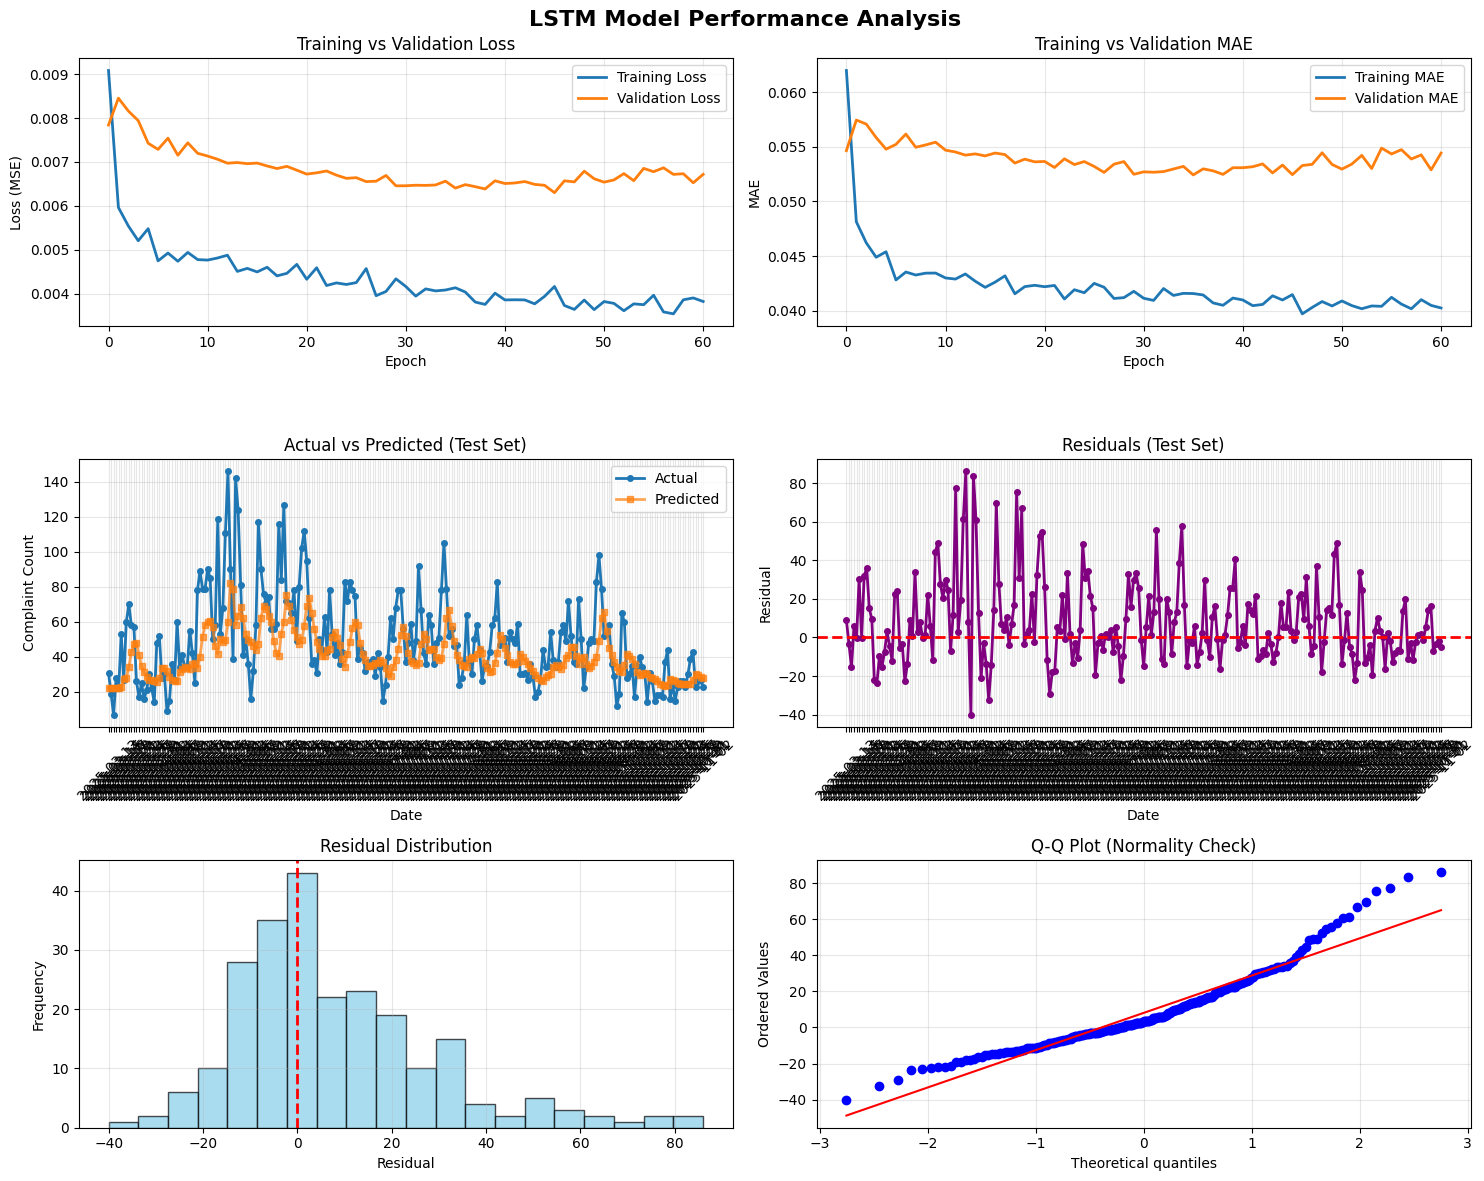

In [31]:
# 4. VISUALIZATIONS

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('LSTM Model Performance Analysis', fontsize=16, fontweight='bold')

# Plot 1: Training vs Validation Loss
axes[0, 0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0, 0].set_title('Training vs Validation Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss (MSE)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Training vs Validation MAE
axes[0, 1].plot(history.history['mae'], label='Training MAE', linewidth=2)
axes[0, 1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
axes[0, 1].set_title('Training vs Validation MAE')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MAE')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Actual vs Predicted (Test Set)
test_dates = df.index[train_size + seq_length:]
axes[1, 0].plot(test_dates, y_test_actual, 'o-', label='Actual', linewidth=2, markersize=4)
axes[1, 0].plot(test_dates, y_test_pred, 's-', label='Predicted', linewidth=2, markersize=4, alpha=0.7)
axes[1, 0].set_title('Actual vs Predicted (Test Set)')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Complaint Count')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

# Plot 4: Residuals
residuals = y_test_actual - y_test_pred
axes[1, 1].plot(test_dates, residuals, 'o-', color='purple', linewidth=2, markersize=4)
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_title('Residuals (Test Set)')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Residual')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=45)

# Plot 5: Residual Distribution
axes[2, 0].hist(residuals, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[2, 0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[2, 0].set_title('Residual Distribution')
axes[2, 0].set_xlabel('Residual')
axes[2, 0].set_ylabel('Frequency')
axes[2, 0].grid(True, alpha=0.3)

# Plot 6: Q-Q Plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[2, 1])
axes[2, 1].set_title('Q-Q Plot (Normality Check)')
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()  